Importing importants modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
np.random.seed(42)

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold,StratifiedKFold ,GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

loading the datasets

In [ ]:
# Load files
train = pd.read_csv('drive/MyDrive/UmojaHack@2022/biginer/train.csv', parse_dates = ['Datetime'])
test = pd.read_csv('drive/MyDrive/UmojaHack@2022/biginer/test.csv', parse_dates = ['Datetime'])
samplesubmission = pd.read_csv('drive/MyDrive/UmojaHack@2022/biginer/SampleSubmission.csv')

# Preview train dataset
train.head()

,ID,Datetime,Sensor1_PM2.5,Sensor2_PM2.5,Temperature,Relative_Humidity,Offset_fault
0,ID_QF0ZTQJ2SF5Q,2021-11-03 04:06:31,52.58,49.52,17.4,96.0,0
1,ID_4GTK689CNX5S,2021-11-08 18:43:23,35.25,33.40,25.0,75.0,0
2,ID_DL7VVKW9U7XQ,2021-11-07 09:50:33,19.18,23.50,24.9,75.0,0
3,ID_6XQOMBXM2DG3,2022-01-01 18:55:15,19.40,15.48,24.9,70.0,0
4,ID_UQZW9ISJY9QE,2021-11-05 22:23:48,38.30,34.77,20.9,89.0,0


#Data Preprocessing & EDA

Checking for missing values

In [ ]:
#Checking the nulll vakues
train.isnull().sum()

ID                      0
Datetime                0
Sensor1_PM2.5        3614
Sensor2_PM2.5        3614
Temperature          3549
Relative_Humidity    3549
Offset_fault            0
dtype: int64

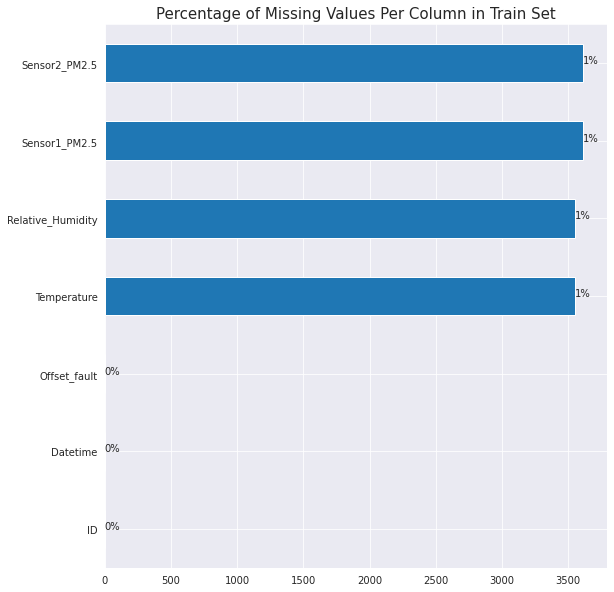

In [ ]:
# Plot missing values in train set
ax = train.isna().sum().sort_values().plot(kind = 'barh', figsize = (9, 10))
plt.title('Percentage of Missing Values Per Column in Train Set', fontdict={'size':15})
for p in ax.patches:
    percentage ='{:,.0f}%'.format((p.get_width()/train.shape[0])*100)
    width, height =p.get_width(),p.get_height()
    x=p.get_x()+width+0.02
    y=p.get_y()+height/2
    ax.annotate(percentage,(x,y))

from above you can see that there are null values in the four columns

In [ ]:
test.isnull().sum()

ID                       0
Datetime                 0
Sensor1_PM2.5            0
Sensor2_PM2.5            0
Temperature          88090
Relative_Humidity    88090
dtype: int64

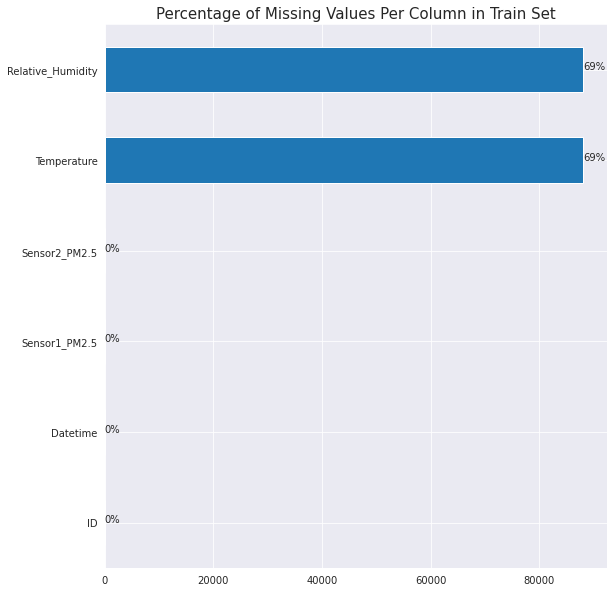

In [ ]:
# Plot missing values in train set
ax = test.isna().sum().sort_values().plot(kind = 'barh', figsize = (9, 10))
plt.title('Percentage of Missing Values Per Column in Train Set', fontdict={'size':15})
for p in ax.patches:
    percentage ='{:,.0f}%'.format((p.get_width()/test.shape[0])*100)
    width, height =p.get_width(),p.get_height()
    x=p.get_x()+width+0.02
    y=p.get_y()+height/2
    ax.annotate(percentage,(x,y))

from above you can see that in our data sets null values occour only in Temperature and Relative_Humidity column

Checking for the outlies

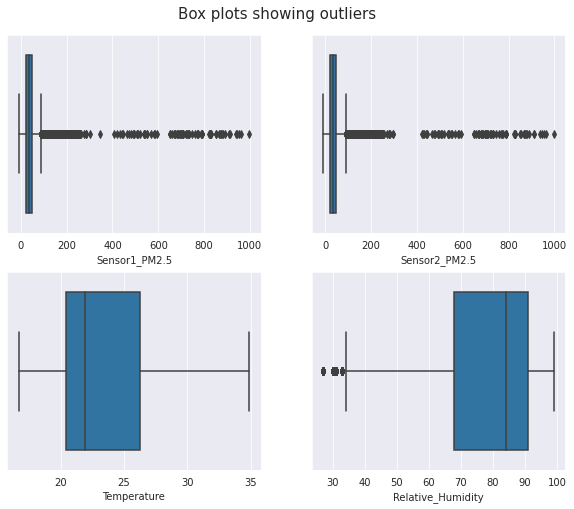

In [ ]:
# Plotting boxplots for each of the numerical columns
sns.set_style('darkgrid')
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))
fig.suptitle('Box plots showing outliers', y= 0.93, fontsize = 15)

for ax, data, name in zip(axes.flatten(), train, ['Sensor1_PM2.5',	'Sensor2_PM2.5',	'Temperature',	'Relative_Humidity']):
  sns.boxplot(train[name], ax = ax)

From above you can see there are many outliers in the Sensor1_PM2.5 and Sensor2_PM2.5

### Target variable distribution

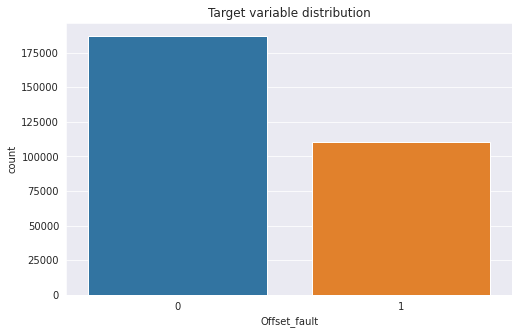

In [ ]:
# Target variable distribution
sns.set_style('darkgrid')
plt.figure(figsize=(8, 5))
sns.countplot(train["Offset_fault"])
plt.title('Target variable distribution')
plt.show()

From above you can see that our data are not well balanced so we will try to apply some methods and algorithms so as to deal with those imbalance

#### Handling missing values and outliers

In [ ]:
#We are going to fill null values with some random number 200, i do this cause it work best for me
train['Sensor1_PM2.5'] = train['Sensor1_PM2.5'].fillna(200)
train['Sensor2_PM2.5'] = train['Sensor2_PM2.5'].fillna(200)

In [ ]:
#and I will fill null values from Temperature and Relative_Humidity column using a meadian because it does not affected much by outliers
train['Relative_Humidity']=train['Relative_Humidity'].fillna(train['Relative_Humidity'].median())
test['Relative_Humidity']=test['Relative_Humidity'].fillna(test['Relative_Humidity'].median())

In [ ]:
train['Temperature']=train['Temperature'].fillna(train['Temperature'].median())
test['Temperature']=test['Temperature'].fillna(test['Temperature'].median())

In [ ]:
train.isnull().sum()

ID                   0
Datetime             0
Sensor1_PM2.5        0
Sensor2_PM2.5        0
Temperature          0
Relative_Humidity    0
Offset_fault         0
dtype: int64

### NOTE
I will not deal with the outliers cause i think they are most usefull to deal with so i will let them

## Feature Engineering

In [ ]:
train['ratio']=train['Sensor1_PM2.5']/train['Sensor2_PM2.5']
train['level'] = pd.cut(train['Relative_Humidity'], bins=[0, 80, 90, float('Inf')], labels=['low', 'medium', 'high'])

# month
train['Datetime_month'] = train.Datetime.dt.month

# year
##train['Datetime_year'] = train.Datetime.dt.year

# hour
train['Datetime_hour'] = train.Datetime.dt.hour


In [ ]:
test['ratio']=test['Sensor1_PM2.5']/test['Sensor2_PM2.5']
test['level'] = pd.cut(test['Relative_Humidity'], bins=[0, 80, 90, float('Inf')], labels=['low', 'medium', 'high'])
# month
test['Datetime_month'] = test.Datetime.dt.month

# year
#test['Datetime_year'] = test.Datetime.dt.year

# hour
test['Datetime_hour'] = test.Datetime.dt.hour


Dropping columns

In [ ]:
train=train.drop(['ID','Datetime'],axis=1)
test=test.drop(['ID','Datetime'],axis=1)

Apply get_dummies

In [ ]:
train=pd.get_dummies(train)
test=pd.get_dummies(test)

# Model Training

In [ ]:

X = train.drop(['Offset_fault'],axis=1)
y = train.Offset_fault

#splitting training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


### Carboost Model

In [ ]:
!pip install catboost #installing a model

     |████████████████████████████████| 76.1 MB 42 kB/s 


model defining

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
categorical_features_indices=[0]
rf1_2 = CatBoostClassifier(learning_rate=0.1,
                          n_estimators=1000,
                          subsample=0.8,
                          max_depth=6,
                          random_state=42,
                          verbose=100,
                          l2_leaf_reg = 6,
                          bootstrap_type="Bernoulli",
                          class_weights=[1, 1],
                          loss_function='MultiClass')

model fitting

In [ ]:
rf1_2.fit(X_train, y_train)

# Making predictions
y_pred = rf1_2.predict(X_test)

# Measuring the accuracy of the model
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}')
print('\n')
print(f'{classification_report(y_test, y_pred)}')

0:	learn: 0.6241695	total: 199ms	remaining: 3m 18s
100:	learn: 0.1693538	total: 12.9s	remaining: 1m 54s
200:	learn: 0.1561041	total: 19s	remaining: 1m 15s
300:	learn: 0.1485074	total: 25.1s	remaining: 58.2s
400:	learn: 0.1426781	total: 31.2s	remaining: 46.6s
500:	learn: 0.1381356	total: 37.3s	remaining: 37.2s
600:	learn: 0.1342209	total: 43.4s	remaining: 28.8s
700:	learn: 0.1307920	total: 49.6s	remaining: 21.1s
800:	learn: 0.1282189	total: 55.6s	remaining: 13.8s
900:	learn: 0.1255118	total: 1m 1s	remaining: 6.78s
999:	learn: 0.1231113	total: 1m 7s	remaining: 0us
Accuracy score: 0.9502321825156471


              precision    recall  f1-score   support

           0       0.96      0.96      0.96     56090
           1       0.93      0.93      0.93     33064

    accuracy                           0.95     89154
   macro avg       0.95      0.95      0.95     89154
weighted avg       0.95      0.95      0.95     89154



From above we got a 95% accuracy

Creating prediction from the test data provided

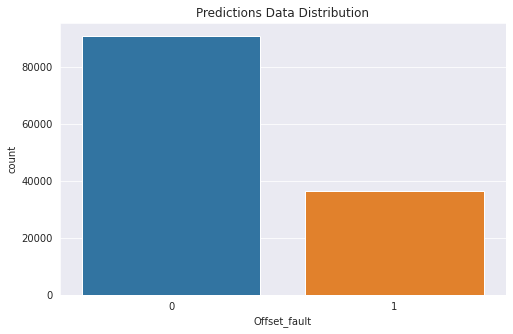

In [ ]:
# Make prediction on the test set
test_df = test
predictions = rf1_2.predict(test_df)

# # Create a submission file
sub_file = samplesubmission.copy()
sub_file.Offset_fault = predictions

# Check the distribution of your predictions
plt.figure(figsize=(8, 5))
sns.countplot(sub_file.Offset_fault)
plt.title('Predictions Data Distribution');

Saving our predictions

In [ ]:
# Create file
sub_file.to_csv('drive/MyDrive/UmojaHack@2022/biginer/107.csv', index = False)